# Домашнее задание №2

рынок: Франция <br>
период: 2023 год

Гайфиев Иван, <br>
Цирулёв Дмитрий, <br>
Прокопец Артём,<br>
23КНТ-6

### Задание 1: Efficient frontier.
Выбрать на рынке набор из 50 акций. Объясните ваш выбор (целью является
построение портфеля инвестиций из выбранных активов). Построить эффективный фронт портфелей
инвестиций без ограничений на короткие позиции и эффективный фронт с запретом коротких
позиций. Сравнить эффективные фронты и сделать выводы. При построении эффективных фронтов
вычислить портфели с минимальным риском и отметить их на соответствующем эффективном
фронте. Рассмотреть портфель с равными долями вложения капитала и оценить, как далек этот
портфель от эффективного фронта. Тот же вопрос для индекса рынка.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
from scipy.optimize import minimize
import seaborn as sns

stocks_50 = pd.read_csv("/content/french_stocks_50.csv", sep=";")
cac = pd.read_csv("/content/CAC40.csv",sep=";")
stocks_50 = stocks_50.dropna()
cac = cac.dropna()

### Задание 2: Portfolio selection problem.
Требуется построить «хорошие» инвестиционные портфели из 10
активов вместо исходных 50 (или даже всех активов рынка). Предложите способ выбрать 10 активов
(из отобранных ранее 50) для формирования портфеля. Сравните эффективные фронты всего набора
(50 акций) и выбранного набора активов (10 акций) для двух случаев
- короткие продажи разрешены,
- короткие продажи запрещены.
Если результат сравнения показывает, что выбор 10 активов не очень удачный, подумайте, как
сделать лучший выбор.

### Задание 3: Risk aversion.
Оцените свое отношение к риску и постройте свой личный оптимальный портфель
инвестиций из выбранных 50 активов. Дайте характеристику портфеля по составу и долям активов.
Оцените VaR и CVaR портфеля. Сделайте выводы. Рассмотрите два случая:
- короткие продажи разрешены,
- короткие продажи запрещены.

### Решение:
Наша команда предпочитает консервативный подход в инвестировании, поэтому мы ориентируемся на составление оптимального портфеля с минимально возможным риском.

In [29]:
# Get lognormal returns
log_returns = (np.log(stocks_50.iloc[:,1:]/stocks_50.iloc[:,1:].shift(1))).dropna()

# Calculate covariance matrix (it helps to get the most optimal combination with minimal risk)
cov_matr = log_returns.cov()*254

# Calculate standard deviation
def std_dev(weights, cov_matr):
  variance = weights.T @ cov_matr @ weights
  return np.sqrt(variance)

# Calculate expected returns
def exp_ret(weights, log_ret):
  return np.sum(log_ret.mean()*weights)*254

# Calculate the Sharpe Ratio
def sharp_rat(weights, log_ret, cov_matr, risk_free_rate):
  return (exp_ret(weights, log_ret) - risk_free_rate) / std_dev(weights, cov_matr)

In [61]:
# OPTIMIZATION PROCESS

# Treasury rate is taken from here: https://www.investing.com/rates-bonds/france-10-year-bond-yield-historical-data
risk_free_rate = 0.03523

# Function to minimize
def neg_sharp(weights, log_ret, cov_matr, risk_free_rate):
  return -sharp_rat(weights, log_ret, cov_matr, risk_free_rate)

# Set constraints
constraints = {'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1}
bounds_s = [(-1, 1) for _ in range(len(log_returns.columns))] # short positions are allowed
bounds_l = [(0, 1) for _ in range(len(log_returns.columns))] # short positions are not allowed

# Set initial weights
initial_weights = np.array([1/len(log_returns.columns)] * len(log_returns.columns))

# Optimize weights to maximize Sharp Ratio
# SLSQ - Sequential Least Squares Quadratic Programming
optimized_results = minimize(neg_sharp, initial_weights, args=(log_returns, cov_matr, risk_free_rate), method='SLSQP', constraints=constraints, bounds=bounds_l)
optimal_weights = optimized_results.x

In [62]:
# PRINTING OPTIMIZATION RESULTS (only for long position/ I should edit it)
print('Optimal weights:')
for col, weight in zip(log_returns.columns, optimal_weights):
  print(f"For company {col} optimal weights is {weight:.4f}")

optimal_portfolio_return = exp_ret(optimal_weights, log_returns)
optimal_portfolio_volatility = std_dev(optimal_weights, cov_matr)
optimal_sharp_ratio = sharp_rat(optimal_weights, log_returns, cov_matr, risk_free_rate)

print(f"Expected annual return: {optimal_portfolio_return:.4f}")
print(f"Expected volatility: {optimal_portfolio_volatility:.4f}")
print(f"Sharp Ratio: {optimal_sharp_ratio:.4f}")

Optimal weights:
For company Stellantis NV optimal weights is 0.0368
For company DNXcorp SA optimal weights is 0.0466
For company IDI optimal weights is 0.0992
For company Credit Agricole optimal weights is 0.0000
For company Accor optimal weights is 0.0000
For company Viel et Cie SA optimal weights is 0.0639
For company Air Liquide optimal weights is 0.0000
For company Publicis optimal weights is 0.0061
For company Safran optimal weights is 0.0000
For company Vicat optimal weights is 0.0140
For company L'Oreal optimal weights is 0.0000
For company Saint Gobain optimal weights is 0.0000
For company Voyageurs du Monde SA optimal weights is 0.0552
For company Groupe Guillin optimal weights is 0.0418
For company Quadient optimal weights is 0.0000
For company Roche Bobois optimal weights is 0.0308
For company Virbac optimal weights is 0.0228
For company Elis Services SA optimal weights is 0.0000
For company Schneider Electric optimal weights is 0.0000
For company Engie optimal weights is 0

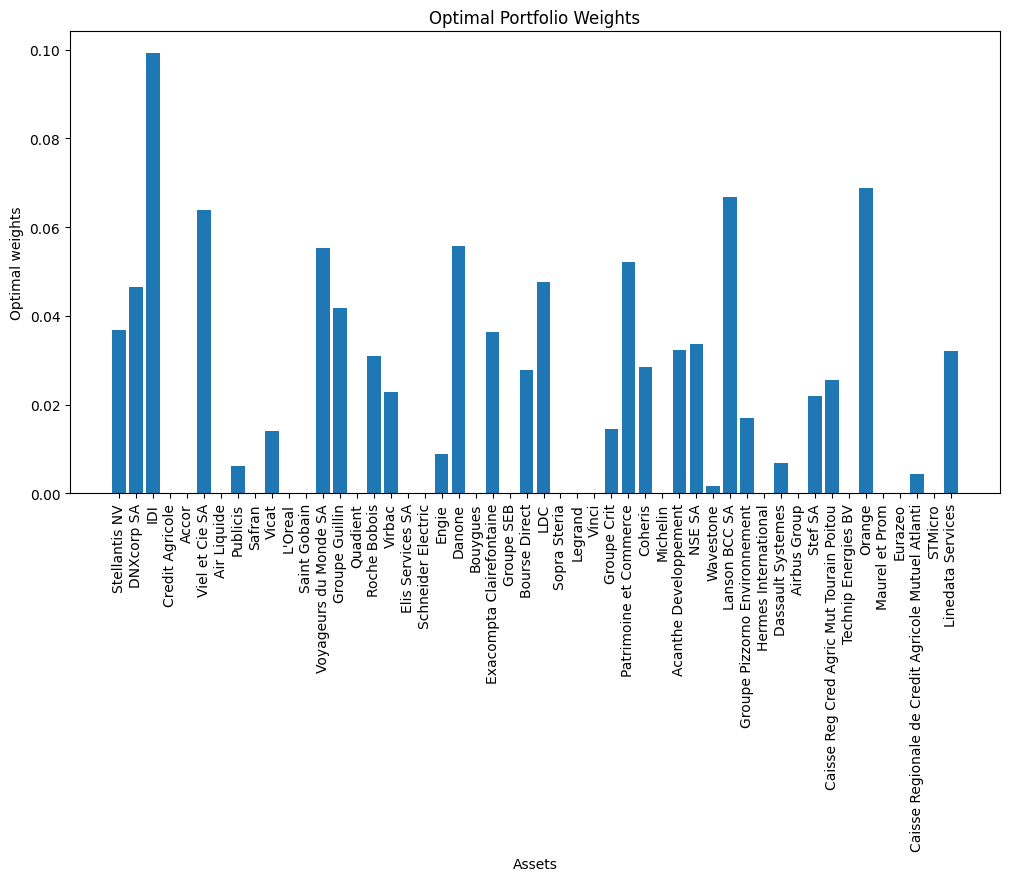

In [63]:
# DISPLAY OPTIMIZATION RESULTS
plt.figure(figsize=(12,6))
plt.bar(log_returns.columns, optimal_weights)

plt.xlabel('Assets')
plt.xticks(rotation=90)
plt.ylabel('Optimal weights')
plt.title('Optimal Portfolio Weights')

plt.show()

**ЗАМЕТКИ**<br><br>

нужно добавить переменные и немного поменять код под два разных случая: короткие продажи разрешены и запрещены <br>

Добавить графики и диаграммы для визуализации и для более интуитивно понятного представления<br>

ВАР и СиВАР посчитать и оценить <br>

Комментарий: почему для оптимизации выбран коэффициент Шарпа, как работает оптимизация, какие результаты, почему; в чём отличие результатов при коротких и длинных позициях. как объясняются доли которые получили активы.

### Задание 4: Markowitz-Tobin model.
Рассмотрите набор активов, отобранных в п.2 (10 активов). Выберете
безрисковый актив (можно виртуальный). Постройте рыночный (оптимальный) портфель. Сделайте
анализ долей активов рыночного портфеля. Оцените VaR и CVaR портфеля. Сделайте выводы.
Рассмотрите два случая:
- короткие продажи разрешены,
- короткие продажи запрещены.

###Задание 5: One factor model.
Рассмотрите набор активов, отобранных в п.2 (10 активов). Проверьте
выполнение условий модели с одним фактором, выбрав в качестве фактора индекс рынка. Считая
модель адекватной найдите рыночный портфель для этого набора активов (воспользуйтесь формулой
весов оптимального портфеля в модели с одним фактором). Сравните его с портфелем п.4.

### Индекс рынка.
Разберитесь, как составляется портфель индекса (определите веса, с которыми
активы входят в индекс). Дайте характеристику индекса (гистограмма, распределение, выбросы).
Найдите собственные значения матрицы ковариаций активов индекса. Что необычного в
распределении собственных значений? На основе метода главных компонент предложите свою
модель индекса рынка. Сравните ваш индекс с индексом рынка.